# TabNet for Just-In-Time Defect Prediction (v1 Features)

Trains a TabNet classifier on the 12 structured commit-level metrics
produced by the v1 preprocessing pipeline. TabNet uses sequential
attention to select which features matter most for each individual
prediction, in contrast to the Deep MLP's uniform treatment of all
features. This notebook establishes the v1-feature TabNet baseline,
directly comparable to the v1 Deep MLP baseline.

## 1. Environment Setup

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00


In [3]:
import os
import json
import random

import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, auc,
)
import matplotlib.pyplot as plt

## 2. Configuration

In [4]:
DATA_DIR = "/content/drive/MyDrive/DL-Assignment/data/processed"
RESULTS_DIR = "/content/drive/MyDrive/DL-Assignment/results/tabnet_v1"

RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

N_D = 8            # width of the decision prediction layer
N_A = 8            # width of the attention embedding (n_d == n_a is the recommended default)
N_STEPS = 3         # number of sequential attention steps
GAMMA = 1.3         # feature reusage coefficient across steps
LAMBDA_SPARSE = 1e-3

MAX_EPOCHS = 100
PATIENCE = 10
BATCH_SIZE = 256
VIRTUAL_BATCH_SIZE = 128
LEARNING_RATE = 2e-2

os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed: int) -> None:
    """Fix random seeds across all libraries for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


## 3. Load Preprocessed Artifacts

Identical artifacts to the v1 Deep MLP notebook, ensuring the
MLP-vs-TabNet comparison on raw features is controlled.

In [5]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))
class_weights = np.load(os.path.join(DATA_DIR, "class_weights.npy"))

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"Class weights [clean, buggy]: {class_weights}")

X_train: (52133, 12)  X_val: (24430, 12)  X_test: (30111, 12)
Class weights [clean, buggy]: [0.7051289  1.71874588]


## 4. Class Weighting

TabNetClassifier accepts a dict mapping class index to sample
weight, applied identically in spirit to the weighted
CrossEntropyLoss used for Deep MLP: the buggy (minority) class is
penalized more heavily during training.

In [6]:
weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print(f"TabNet class weight dict: {weight_dict}")

TabNet class weight dict: {0: 0.7051288987475316, 1: 1.7187458789397336}


## 5. Model Definition

TabNet hyperparameters follow the original paper's recommended
defaults for small-to-medium tabular datasets (n_d = n_a = 8,
n_steps = 3, gamma = 1.3), rather than an exhaustive search, given
the four-model comparison scope of this project.

In [7]:
tabnet_params = dict(
    n_d=N_D,
    n_a=N_A,
    n_steps=N_STEPS,
    gamma=GAMMA,
    lambda_sparse=LAMBDA_SPARSE,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=LEARNING_RATE),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=20, gamma=0.5),
    mask_type="entmax",
    seed=RANDOM_SEED,
    device_name=DEVICE,
    verbose=1,
)

In [18]:
num_trainable_params = sum(p.numel() for p in model.network.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_trainable_params}")

Number of trainable parameters: 6440


## 6. Training with Early Stopping

`eval_set` supplies the validation partition; training stops if
validation AUC does not improve for `PATIENCE` epochs, and the best
epoch's weights are restored automatically by pytorch-tabnet.

In [8]:
import time

model = TabNetClassifier(**tabnet_params)

start_time = time.time()
model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=["train", "val"],
    eval_metric=["auc"],
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    weights=weight_dict,
    drop_last=False,
)
end_time = time.time()
training_time = end_time - start_time
print(f"\nModel training completed in {training_time:.2f} seconds.")

/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.61166 | train_auc: 0.76157 | val_auc: 0.76575 |  0:00:09s
epoch 1  | loss: 0.58604 | train_auc: 0.76874 | val_auc: 0.7779  |  0:00:17s
epoch 2  | loss: 0.57582 | train_auc: 0.77021 | val_auc: 0.77682 |  0:00:24s
epoch 3  | loss: 0.57083 | train_auc: 0.76475 | val_auc: 0.75886 |  0:00:40s
epoch 4  | loss: 0.57209 | train_auc: 0.77278 | val_auc: 0.77146 |  0:00:48s
epoch 5  | loss: 0.56143 | train_auc: 0.77267 | val_auc: 0.78451 |  0:00:56s
epoch 6  | loss: 0.56396 | train_auc: 0.78472 | val_auc: 0.78658 |  0:01:03s
epoch 7  | loss: 0.56321 | train_auc: 0.78008 | val_auc: 0.77717 |  0:01:11s
epoch 8  | loss: 0.55914 | train_auc: 0.779   | val_auc: 0.7758  |  0:01:19s
epoch 9  | loss: 0.55945 | train_auc: 0.7836  | val_auc: 0.78597 |  0:01:27s
epoch 10 | loss: 0.56095 | train_auc: 0.78484 | val_auc: 0.79164 |  0:01:34s
epoch 11 | loss: 0.55741 | train_auc: 0.78158 | val_auc: 0.7843  |  0:01:43s
epoch 12 | loss: 0.55522 | train_auc: 0.77696 | val_auc: 0.77914 |  0:01:50s

/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Model training completed in 247.36 seconds.


## 7. Training Curves

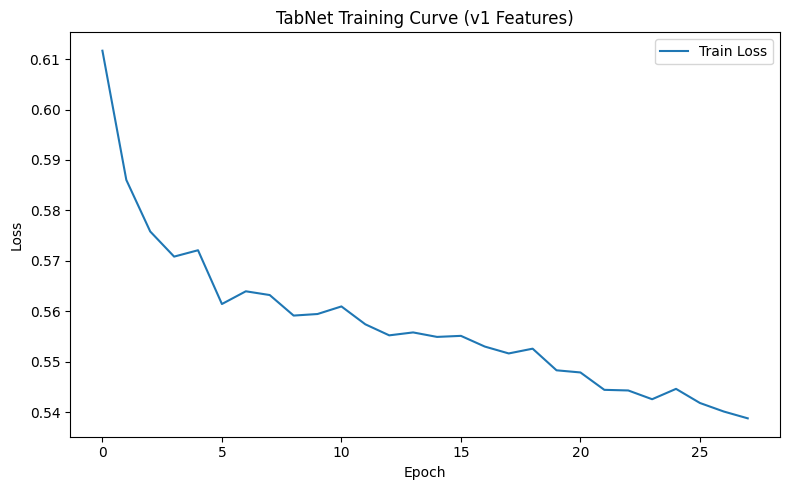

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(model.history["loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TabNet Training Curve (v1 Features)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curve.png"))
plt.show()

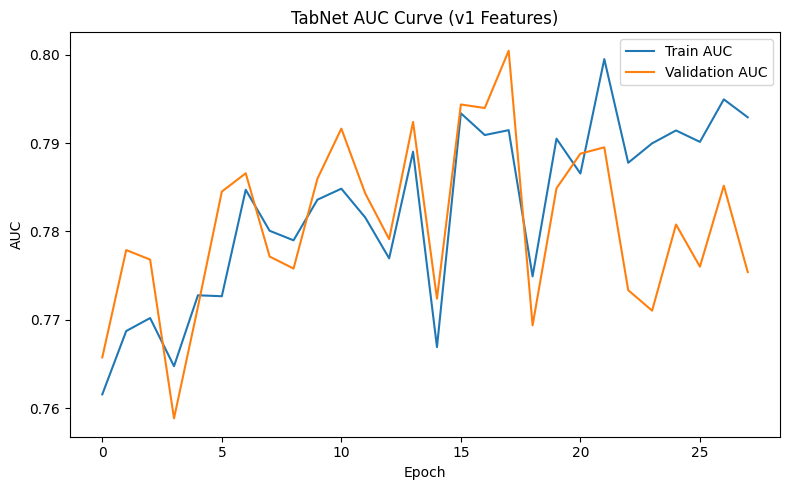

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(model.history["train_auc"], label="Train AUC")
plt.plot(model.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("TabNet AUC Curve (v1 Features)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "auc_curve.png"))
plt.show()

## 8. Threshold Selection on Validation Set

As with Deep MLP, the decision threshold is tuned on the validation
set (never the test set) to select the F1-maximizing cutoff rather
than assuming the default 0.5.

In [11]:
val_probs = model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
val_f1_scores = [
    f1_score(y_val, (val_probs >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_threshold = float(thresholds[np.argmax(val_f1_scores)])

print(f"Best threshold on validation set: {best_threshold:.2f} (val F1={max(val_f1_scores):.4f})")

Best threshold on validation set: 0.41 (val F1=0.6194)


## 9. Evaluation

Final evaluation is performed once on the held-out test set
(2017-2019 commits), using the validation-selected threshold.

In [12]:
test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)
pr_auc = auc(recall_curve, precision_curve)

metrics = {
    "threshold": best_threshold,
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "pr_auc": pr_auc,
}

for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

threshold : 0.4100
accuracy  : 0.6537
precision : 0.3362
recall    : 0.8128
f1        : 0.4756
roc_auc   : 0.7835
pr_auc    : 0.4530


In [13]:
print(classification_report(y_test, test_preds, target_names=["Clean", "Buggy"]))

              precision    recall  f1-score   support

       Clean       0.93      0.62      0.74     24293
       Buggy       0.34      0.81      0.48      5818

    accuracy                           0.65     30111
   macro avg       0.63      0.71      0.61     30111
weighted avg       0.82      0.65      0.69     30111



## 10. Confusion Matrix

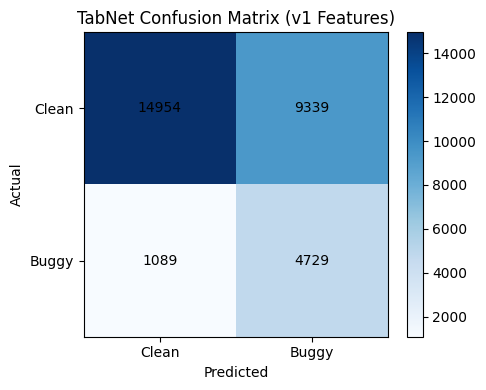

In [14]:
cm = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Clean", "Buggy"])
ax.set_yticklabels(["Clean", "Buggy"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("TabNet Confusion Matrix (v1 Features)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
plt.show()

## 11. Feature Importance

TabNet's key architectural distinction from MLP: per-feature
importance scores derived from its learned attention masks,
providing interpretability that a plain MLP does not offer.

Loaded 12 feature names: ['la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp']


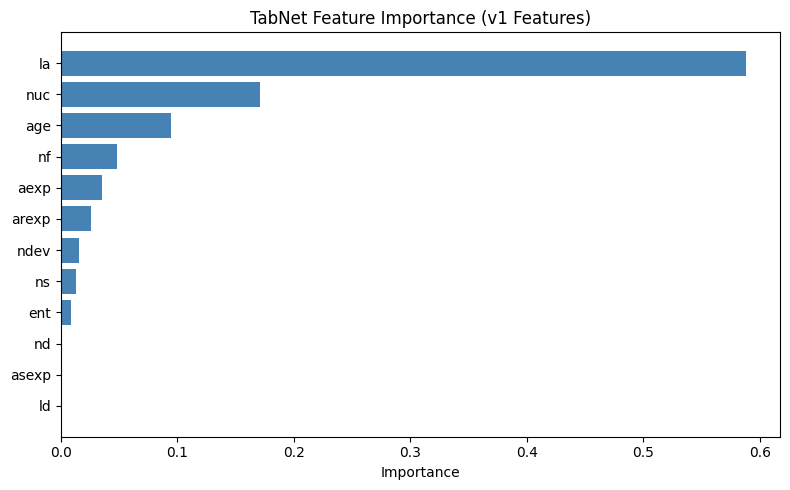

la      : 0.5879
nuc     : 0.1707
age     : 0.0944
nf      : 0.0478
aexp    : 0.0352
arexp   : 0.0261
ndev    : 0.0157
ns      : 0.0133
ent     : 0.0089
nd      : 0.0001
asexp   : 0.0000
ld      : 0.0000


In [15]:
FEATURE_NAMES_PATH = os.path.join(DATA_DIR, "feature_names.txt")
if os.path.exists(FEATURE_NAMES_PATH):
    with open(FEATURE_NAMES_PATH) as f:
        FEATURE_NAMES = f.read().splitlines()
else:
    # v1 preprocessing did not save feature_names.txt; use the known
    # fixed column order from the v1 preprocessing notebook.
    FEATURE_NAMES = ["la", "ld", "nf", "nd", "ns", "ent",
                      "ndev", "age", "nuc", "aexp", "arexp", "asexp"]

print(f"Loaded {len(FEATURE_NAMES)} feature names: {FEATURE_NAMES}")

feature_importances = model.feature_importances_

sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8, 5))
plt.barh(
    [FEATURE_NAMES[i] for i in sorted_idx],
    feature_importances[sorted_idx],
    color="steelblue",
)
plt.xlabel("Importance")
plt.title("TabNet Feature Importance (v1 Features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_importance.png"))
plt.show()

for name, score in sorted(zip(FEATURE_NAMES, feature_importances), key=lambda x: -x[1]):
    print(f"{name:8s}: {score:.4f}")

## 12. Persist Model and Results

In [16]:
model.save_model(os.path.join(RESULTS_DIR, "tabnet_model"))

with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

with open(os.path.join(RESULTS_DIR, "feature_importance.json"), "w") as f:
    json.dump(dict(zip(FEATURE_NAMES, feature_importances.tolist())), f, indent=2)

print(f"Model and results saved to {RESULTS_DIR}")

Successfully saved model at /content/drive/MyDrive/DL-Assignment/results/tabnet_v1/tabnet_model.zip
Model and results saved to /content/drive/MyDrive/DL-Assignment/results/tabnet_v1


## Summary

| Artifact | Description |
|---|---|
| `tabnet_model.zip` | Trained TabNet model |
| `metrics.json` | Test-set accuracy, precision, recall, F1, ROC-AUC, PR-AUC |
| `feature_importance.json` | Per-feature importance scores |
| `training_curve.png` / `auc_curve.png` | Training curves |
| `confusion_matrix.png` | Test-set confusion matrix |
| `feature_importance.png` | Feature importance bar chart |

Compare `metrics.json` against `results/mlp/metrics.json` (v1 Deep
MLP) for the MLP-vs-TabNet comparison on raw features.